In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch


In [2]:
output = pd.read_csv('./feynmantest/internalFunctionSizeTest.csv')

In [3]:
print(output.head())

   Layers  Nodes Function   train MSE    test MSE
0       1      4        x    0.000010    0.000010
1       1      4     x**2    0.038243    0.023983
2       1      4     x**3    1.605753    0.926518
3       1      4     x**4   56.679638   34.492676
4       1      4     x**5  949.018066  503.268524


In [4]:
import pandas as pd

# Read the CSV file
df = pd.read_csv('./feynmantest/internalFunctionSizeTest.csv')

# Group by Layers and Nodes, then calculate median test MSE
median_mse = df.groupby(['Layers', 'Nodes'])['test MSE'].median().reset_index()

# Create pivot table with Layers as columns and Nodes as rows
pivot_table = median_mse.pivot(index='Nodes', columns='Layers', values='test MSE')

# Display the table
print("Median Test MSE by Nodes (Y-axis) and Layers (X-axis):")
print(pivot_table)
print("\n")
print(pivot_table.to_string())


Median Test MSE by Nodes (Y-axis) and Layers (X-axis):
Layers         1         2         3         4         5
Nodes                                                   
4       0.129388  0.077419  0.017634  0.011070  0.026374
8       0.125290  0.016745  0.005608  0.004361  0.001240
16      0.117689  0.014344  0.000886  0.000491  0.000887
32      0.082436  0.007671  0.000879  0.000612  0.000618
64      0.079068  0.004682  0.001119  0.003924  0.001120
128     0.076371  0.003266  0.000332  0.000437  0.000784
256     0.073289  0.003068  0.001148  0.001338  0.002749


Layers         1         2         3         4         5
Nodes                                                   
4       0.129388  0.077419  0.017634  0.011070  0.026374
8       0.125290  0.016745  0.005608  0.004361  0.001240
16      0.117689  0.014344  0.000886  0.000491  0.000887
32      0.082436  0.007671  0.000879  0.000612  0.000618
64      0.079068  0.004682  0.001119  0.003924  0.001120
128     0.076371  0.003266  0.0

In [5]:
# Median difference table: (test MSE - train MSE)
df['mse_diff_test_minus_train'] = df['test MSE'] - df['train MSE']

median_diff = (
    df.groupby(['Layers', 'Nodes'])['mse_diff_test_minus_train']
      .median()
      .reset_index()
)

pivot_diff = median_diff.pivot(index='Nodes', columns='Layers', values='mse_diff_test_minus_train')

print('Median (Test MSE - Train MSE) by Nodes (Y-axis) and Layers (X-axis):')
print(pivot_diff)
print('\n')
print(pivot_diff.to_string())

Median (Test MSE - Train MSE) by Nodes (Y-axis) and Layers (X-axis):
Layers         1         2             3             4             5
Nodes                                                               
4      -0.004727 -0.000334 -2.952626e-04 -8.819049e-05 -8.694388e-04
8      -0.002992 -0.000161 -6.459796e-05 -1.069337e-05 -2.045411e-05
16     -0.001754 -0.000104 -8.368388e-07 -6.883151e-07  1.813942e-08
32     -0.002697 -0.000016 -6.381224e-07  2.074785e-08 -1.209571e-07
64     -0.003326 -0.000016 -2.654508e-08  8.027570e-10  1.031121e-08
128    -0.003678 -0.000006 -1.570418e-07  4.491329e-08  5.062466e-07
256    -0.005162 -0.000004  4.963018e-06 -2.272382e-07 -3.290717e-08


Layers         1         2             3             4             5
Nodes                                                               
4      -0.004727 -0.000334 -2.952626e-04 -8.819049e-05 -8.694388e-04
8      -0.002992 -0.000161 -6.459796e-05 -1.069337e-05 -2.045411e-05
16     -0.001754 -0.000104 -8.36

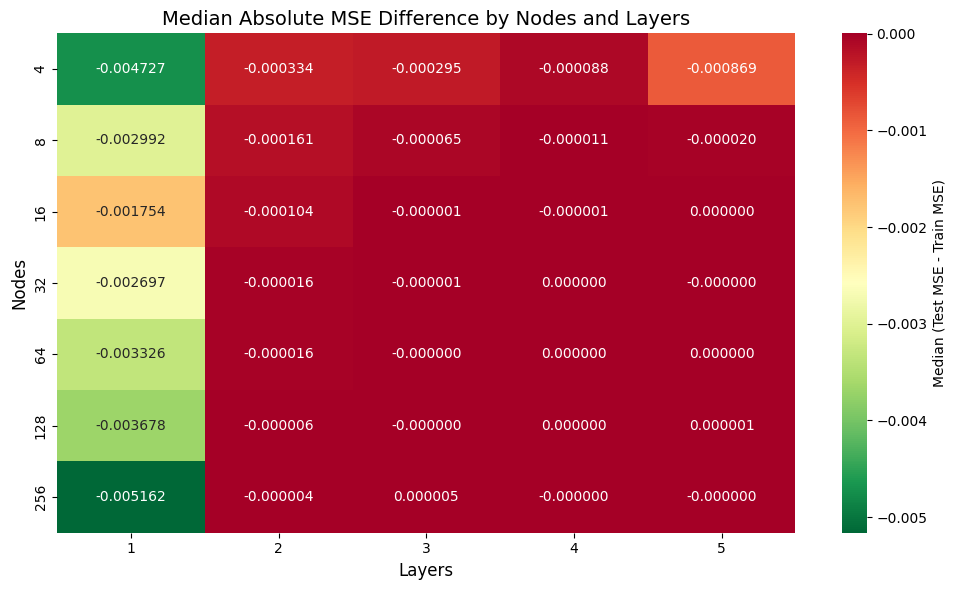

In [6]:
# Heatmap for median absolute difference |test MSE - train MSE|
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    pivot_diff,
    annot=True,
    fmt='.6f',
    cmap='RdYlGn_r',
    cbar_kws={'label': 'Median (Test MSE - Train MSE)'},
    ax=ax
)
ax.set_xlabel('Layers', fontsize=12)
ax.set_ylabel('Nodes', fontsize=12)
ax.set_title('Median Absolute MSE Difference by Nodes and Layers', fontsize=14)
plt.tight_layout()
plt.show()

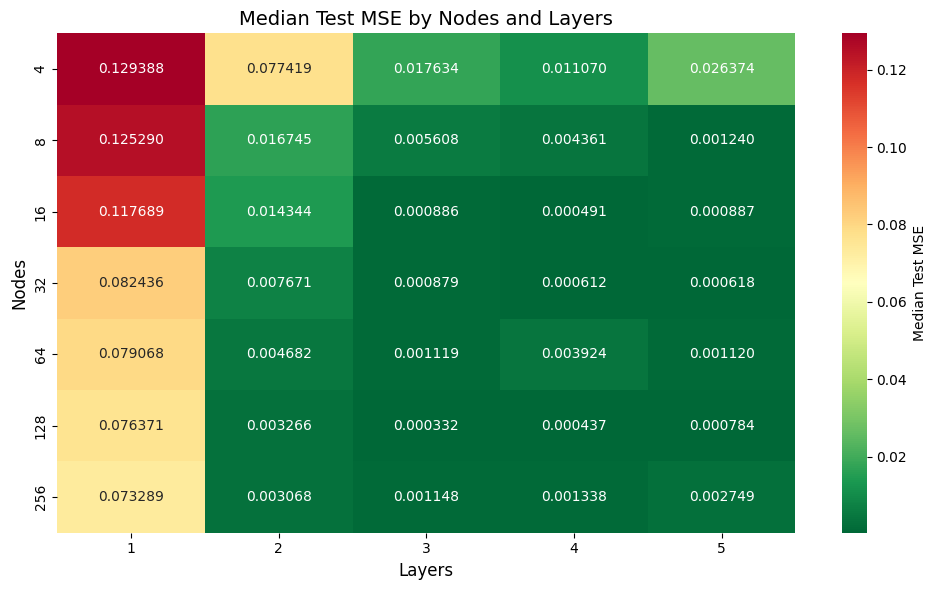

In [7]:

# Create heatmap
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt='.6f', cmap='RdYlGn_r', cbar_kws={'label': 'Median Test MSE'}, ax=ax)
ax.set_xlabel('Layers', fontsize=12)
ax.set_ylabel('Nodes', fontsize=12)
ax.set_title('Median Test MSE by Nodes and Layers', fontsize=14)
plt.tight_layout()
plt.show()


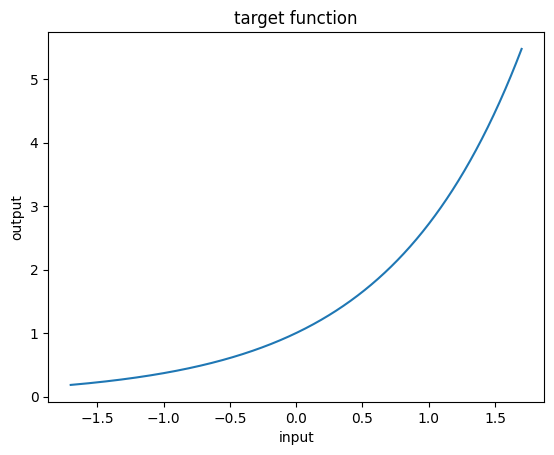

In [10]:
f = lambda x: torch.exp(x[:])
# f = lambda x: torch.log(x**2 + 0.19211827) - 0.61102915
input = torch.linspace(-1.7, 1.7, 1000).unsqueeze(1)
plt.plot(input.detach().cpu(), f(input).detach().cpu())
plt.xlabel("input")
plt.ylabel("output")
plt.title("target function")
plt.show()